# 共现矩阵
统计一个session内同时出现的item对
以
    I like deep learning.
    I like NLP.
    I enjoy flying
为例，语料有"I like deep learning NLP enjoy flying"

在第一个session内，
    I 与 like 共现
    I 与 deep 共现
    I 与 learning 共现
    like 与 deep 共现
    like 与 learning 共现
    deep 与 learning 共现
两两算作一次

统计每个session后得到共现矩阵

In [1]:
import pandas as pd
import numpy as np

In [2]:
train=pd.read_parquet('../data/processData/train.parquet')
test=pd.read_parquet('../data/processData/test.parquet')

sample_sub=pd.read_csv('../data/rawData/sample_submission.csv')

In [4]:
train.head()

,session,aid,ts,type
0,0,1517085,1659304800,0
1,0,1563459,1659304904,0
2,0,1309446,1659367439,0
3,0,16246,1659367719,0
4,0,1781822,1659367871,0


In [5]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6928123 entries, 0 to 6928122
Data columns (total 4 columns):
 #   Column   Dtype
---  ------   -----
 0   session  int32
 1   aid      int32
 2   ts       int32
 3   type     uint8
dtypes: int32(3), uint8(1)
memory usage: 85.9 MB


In [6]:
fraction=1

In [7]:
subset_of_train,subset_of_test=train,test

if fraction!=1:
    # drop_duplicates(['session]) 对session相同的只保留第一个，sample随机抽样
    session_train_set=train.drop_duplicates(['session']).sample(frac=fraction,random_state=42)['session']
    subset_of_train=train[train.session.isin(session_train_set)]

    session_test_set=test.drop_duplicates(['session']).sample(frac=fraction,random_state=42)['session']
    subset_of_test=test[test.session.isin(session_test_set)]

# 提取出session作为索引，方便后续按照session做chunk遍历 [[]]方式取出的是Dataframe
subset_of_train.index=pd.MultiIndex.from_frame(subset_of_train[['session']])
subset_of_test.index=pd.MultiIndex.from_frame(subset_of_test[['session']])

In [8]:
chunk_size=30_000
min_ts = train.ts.min()
max_ts = test.ts.max()


In [9]:
from collections import defaultdict,Counter
next_AIDs=defaultdict(Counter)

# 纵向拼接，使用全量数据
subsets=pd.concat([subset_of_train ,subset_of_test])
sessions=subsets.session.unique()

In [10]:
subsets.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 223644219 entries, (0,) to (14571581,)
Data columns (total 4 columns):
 #   Column   Dtype
---  ------   -----
 0   session  int32
 1   aid      int32
 2   ts       int32
 3   type     uint8
dtypes: int32(3), uint8(1)
memory usage: 4.0 GB


In [9]:
for i in range(0,sessions.shape[0],chunk_size):
    # reset_index(drop=True)重建行索引，丢弃旧索引
    current_chunk=subsets.loc[sessions[i]:sessions[min(sessions.shape[0]-1,i+chunk_size-1)]].reset_index(drop=True)
    # 取出每个session后30个，考虑性能和最近行为
    # as_index保持原有的索引，不用session做索引
    current_chunk=current_chunk.groupby('session',as_index=False).nth(list(range(-30,0))).reset_index(drop=True)
    # 按照session连接，对同一个session内的所有行（不区分属性）做笛卡尔积
    consecutive_AIDs=current_chunk.merge(current_chunk,on='session')
    # 排除自己和自己
    consecutive_AIDs=consecutive_AIDs[consecutive_AIDs.aid_x!=consecutive_AIDs.aid_y]
    # 通过时间戳(>=0)的方式保证两两算一次，不考虑顺序
    consecutive_AIDs['days_elapsed']=(consecutive_AIDs.ts_y-consecutive_AIDs.ts_x)/(24*60*60)
    consecutive_AIDs=consecutive_AIDs[(consecutive_AIDs.days_elapsed>=0) & (consecutive_AIDs.days_elapsed<=1)]

    for aid_x,aid_y in zip(consecutive_AIDs['aid_x'],consecutive_AIDs['aid_y']):
        next_AIDs[aid_x][aid_y]+=1
del train,subset_of_train,subsets


KeyboardInterrupt: 

In [21]:
session_types=['clicks','carts','orders']
# 聚合session
test_session_AIDs=test.reset_index(drop=True).groupby('session')['aid'].apply(list)
test_session_types=test.reset_index(drop=True).groupby('session')['type'].apply(list)

labels=[]

no_data=0 # 输出的预选共现商品为空
no_data_all_aids=0 #无法通过共现矩阵补充预选商品
type_weight_multipliers={0:1,1:6,2:3}
for AIDs,types in zip(test_session_AIDs,test_session_types):
    # 当session的操作数>=20，对操作加权，权重由位置和类型决定
    if len(AIDs)>=20:
        # base底数，endpoint是否包含右边界
        weights=np.logspace(0.1,1,len(AIDs),base=2,endpoint=True)-1
        aids_temp=defaultdict(lambda: 0)
        for aid,w,t in zip(AIDs,weights,types):
            aids_temp[aid]+=w*type_weight_multipliers[t]
        sorted_aids=[k for k,v in sorted(aids_temp.items(),key=lambda item:-item[1])]
        labels.append(sorted_aids[:20]) # 取前20个
    else:
        # 对短序列用共现矩阵补全
        AIDs=list(dict.fromkeys(AIDs[::-1])) # 去重,倒序保证能保留最近的操作
        AIDs_len_start=len(AIDs)
        candidates=[]
        # 为每个商品找到出现次数最多的20个
        for AID in AIDs:
            if AID in next_AIDs:
                # most_common返回出现次数最多的元素及其频次
                candidates+=[aid for aid,count in next_AIDs[AID].most_common(20)]
        # 保证不重复添加到最终结果中
        AIDs+=[AID for AID ,cnt in Counter(candidates).most_common(40) if AID not in AIDs]

        labels.append(AIDs[:20])
        if candidates==[]:no_data+=1
        if AIDs_len_start==len(AIDs):no_data_all_aids+=1

In [23]:
labels_as_strings=[' '.join([str(l) for l in lls]) for lls in labels] # 将预测的结果按转换为用空格分开的字符串

predictions=pd.DataFrame(data={'session_type':test_session_AIDs.index,'labels':labels_as_strings})
prediction_dfs=[]

for st in session_types:
    modified_predictions=predictions.copy()
    modified_predictions.session_type=modified_predictions.session_type.astype('str')+f'_{st}'
    prediction_dfs.append(modified_predictions)

submission=pd.concat(prediction_dfs).reset_index(drop=True)
submission.to_csv('../save/co_visitation_submission.csv',index=False)

In [25]:
print(f'Test sessions that we did not manage to extend based on the co-visitation matrix: {no_data_all_aids}')

Test sessions that we did not manage to extend based on the co-visitation matrix: 1617012


Text(0.5, 0.98, 'Distribution of predicted sequence lengths')

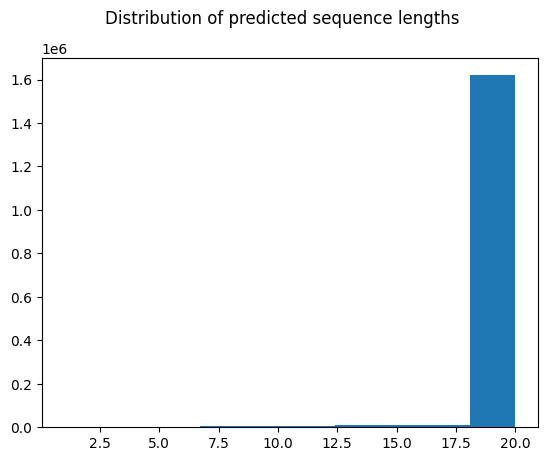

In [26]:
from matplotlib import pyplot as plt

plt.hist([len(i) for i in labels])
plt.suptitle('Distribution of predicted sequence lengths')